Exploratory Data Analysis on 2 Datasets:

1.   go_emotions_Reddit dataset.csv
2.   Sentiment Analysis for Mental Health_reddit.csv

First of all, import and download all necessary packages and libraries.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud, STOPWORDS
from nltk.sentiment import SentimentIntensityAnalyzer
import nltk
import re
import warnings

# Initialize
nltk.download('punkt')
nltk.download('vader_lexicon')
plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (12, 8)
warnings.filterwarnings('ignore')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...


In [2]:
# Text cleaning
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Word cloud generator
def generate_wordcloud(text, title, colormap='viridis'):
    wc = WordCloud(width=1200, height=600,
                  background_color='white',
                  stopwords=set(STOPWORDS),
                  max_words=200,
                  colormap=colormap,
                  contour_width=1).generate(text)
    plt.figure(figsize=(15, 8))
    plt.imshow(wc, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Characteristic Words: {title}', pad=20, fontsize=16)
    plt.tight_layout()
    plt.show()

(1) EDA on go_emotions_Reddit dataset.csv covers the following:
- Word clouds for all 28 emotions
- Distribution analysis
- Sentiment breakdown
- Comprehensive visualizations

1. Emotion Distribution

Loading GoEmotions dataset...

=== EMOTION DISTRIBUTION ===


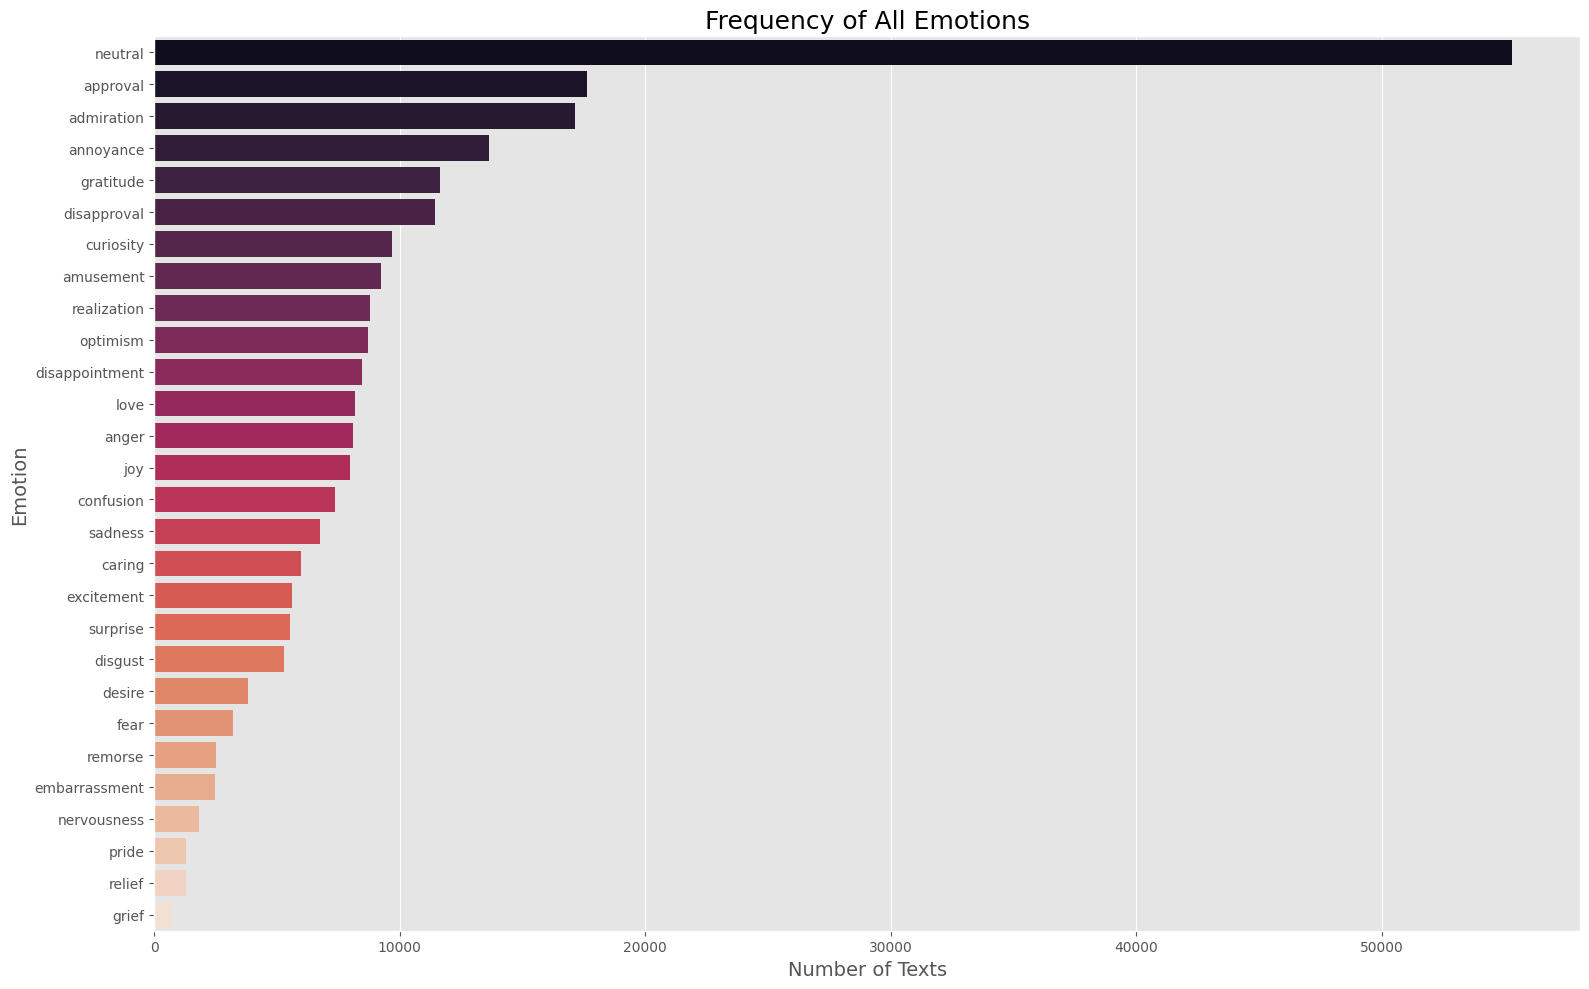

In [3]:
# Load data
print("Loading GoEmotions dataset...")
df = pd.read_csv('go_emotions_Reddit dataset.csv')
df = df[~df['example_very_unclear'].astype(bool)]
emotion_cols = [col for col in df.columns if col not in ['text', 'id', 'example_very_unclear']]
df['cleaned_text'] = df['text'].apply(clean_text)

# 1. Emotion Distribution - ALL EMOTIONS
print("\n=== EMOTION DISTRIBUTION ===")
emotion_counts = df[emotion_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(16, 10))
sns.barplot(x=emotion_counts.values, y=emotion_counts.index, palette='rocket')
plt.title('Frequency of All Emotions', fontsize=18)
plt.xlabel('Number of Texts', fontsize=14)
plt.ylabel('Emotion', fontsize=14)
plt.tight_layout()
plt.show()

2. Word Clouds for all emotions

In [4]:
print("\n=== WORD CLOUDS FOR ALL EMOTIONS ===")
for emotion in emotion_cols:
    texts = df[df[emotion] == 1]['cleaned_text']
    if len(texts) > 0:
        print(f"\nGenerating word cloud for {emotion} ({len(texts)} texts)")
        generate_wordcloud(' '.join(texts.astype(str)), emotion, 'plasma')

Output hidden; open in https://colab.research.google.com to view.

3. Multi-Label Analysis


=== MULTI-LABEL ANALYSIS ===


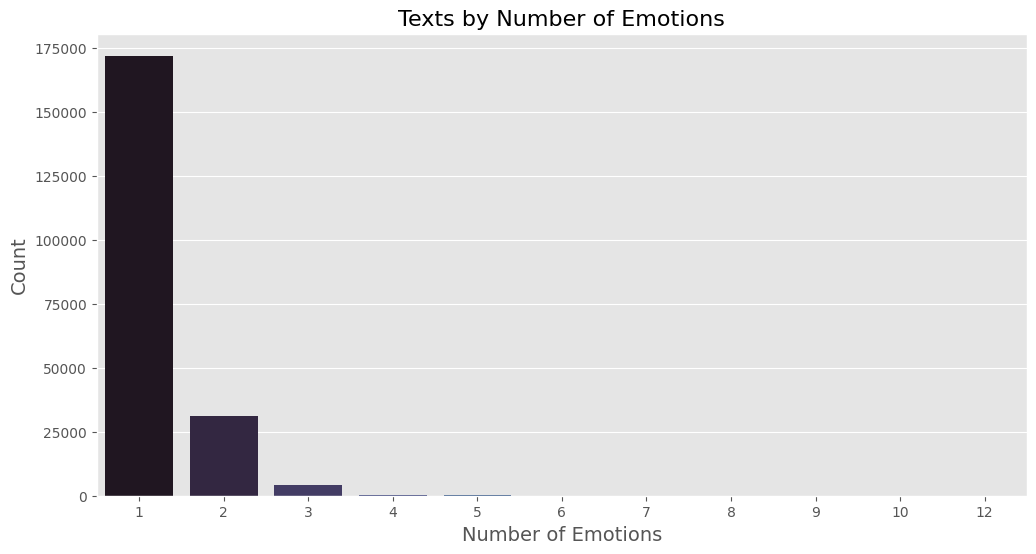

In [5]:
print("\n=== MULTI-LABEL ANALYSIS ===")
df['num_emotions'] = df[emotion_cols].sum(axis=1)
multi_label_dist = df['num_emotions'].value_counts().sort_index()

plt.figure(figsize=(12, 6))
sns.barplot(x=multi_label_dist.index, y=multi_label_dist.values, palette='mako')
plt.title('Texts by Number of Emotions', fontsize=16)
plt.xlabel('Number of Emotions', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.show()

4. Sentiment Analysis by emotions


=== SENTIMENT ANALYSIS BY EMOTION ===


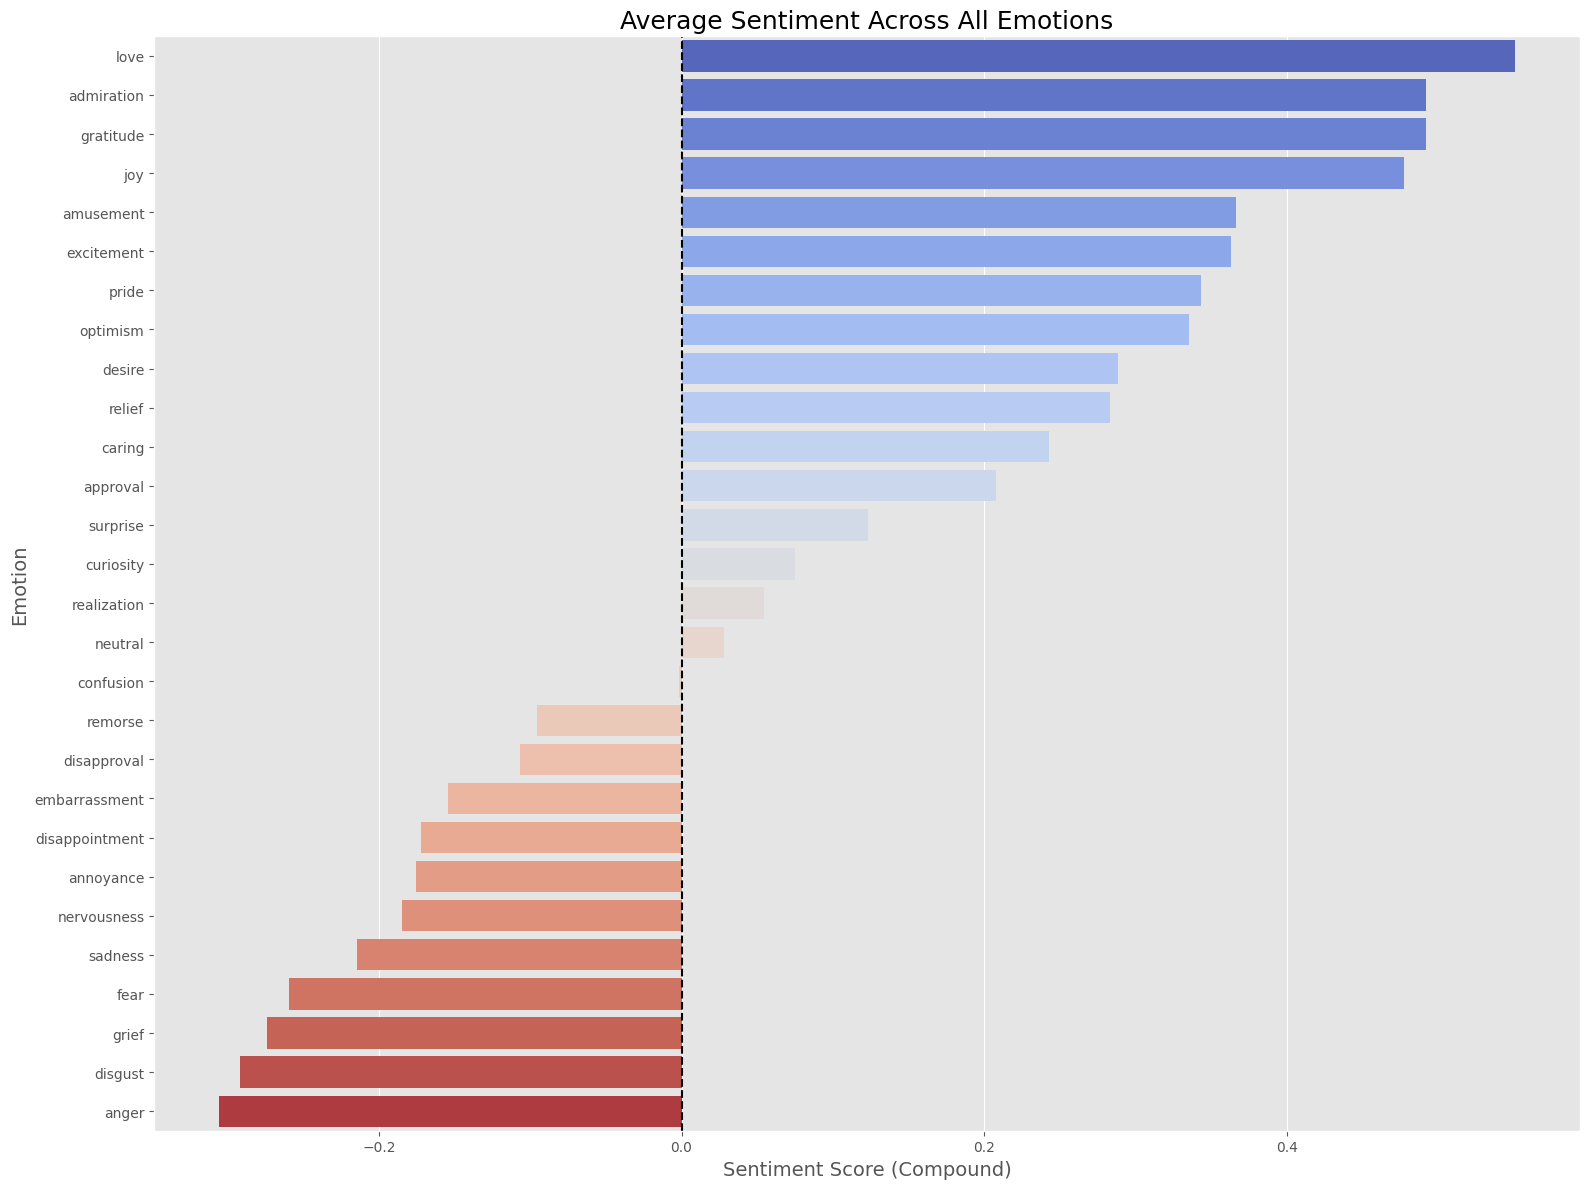

In [6]:
print("\n=== SENTIMENT ANALYSIS BY EMOTION ===")
sia = SentimentIntensityAnalyzer()
sentiment_results = []

for emotion in emotion_cols:
    subset = df[df[emotion] == 1]
    if len(subset) > 0:
        sentiments = subset['cleaned_text'].apply(lambda x: sia.polarity_scores(str(x))['compound'])
        sentiment_results.append({
            'emotion': emotion,
            'count': len(subset),
            'mean_sentiment': sentiments.mean(),
            'median_sentiment': sentiments.median(),
            'min_sentiment': sentiments.min(),
            'max_sentiment': sentiments.max()
        })

# Convert to DataFrame and sort
sentiment_df = pd.DataFrame(sentiment_results).sort_values('mean_sentiment', ascending=False)

# Plot sentiment for all emotions
plt.figure(figsize=(16, 12))
sns.barplot(x='mean_sentiment', y='emotion', data=sentiment_df, palette='coolwarm')
plt.axvline(0, color='black', linestyle='--')
plt.title('Average Sentiment Across All Emotions', fontsize=18)
plt.xlabel('Sentiment Score (Compound)', fontsize=14)
plt.ylabel('Emotion', fontsize=14)
plt.tight_layout()
plt.show()

5. Text Length Analysis


=== TEXT LENGTH BY EMOTION ===


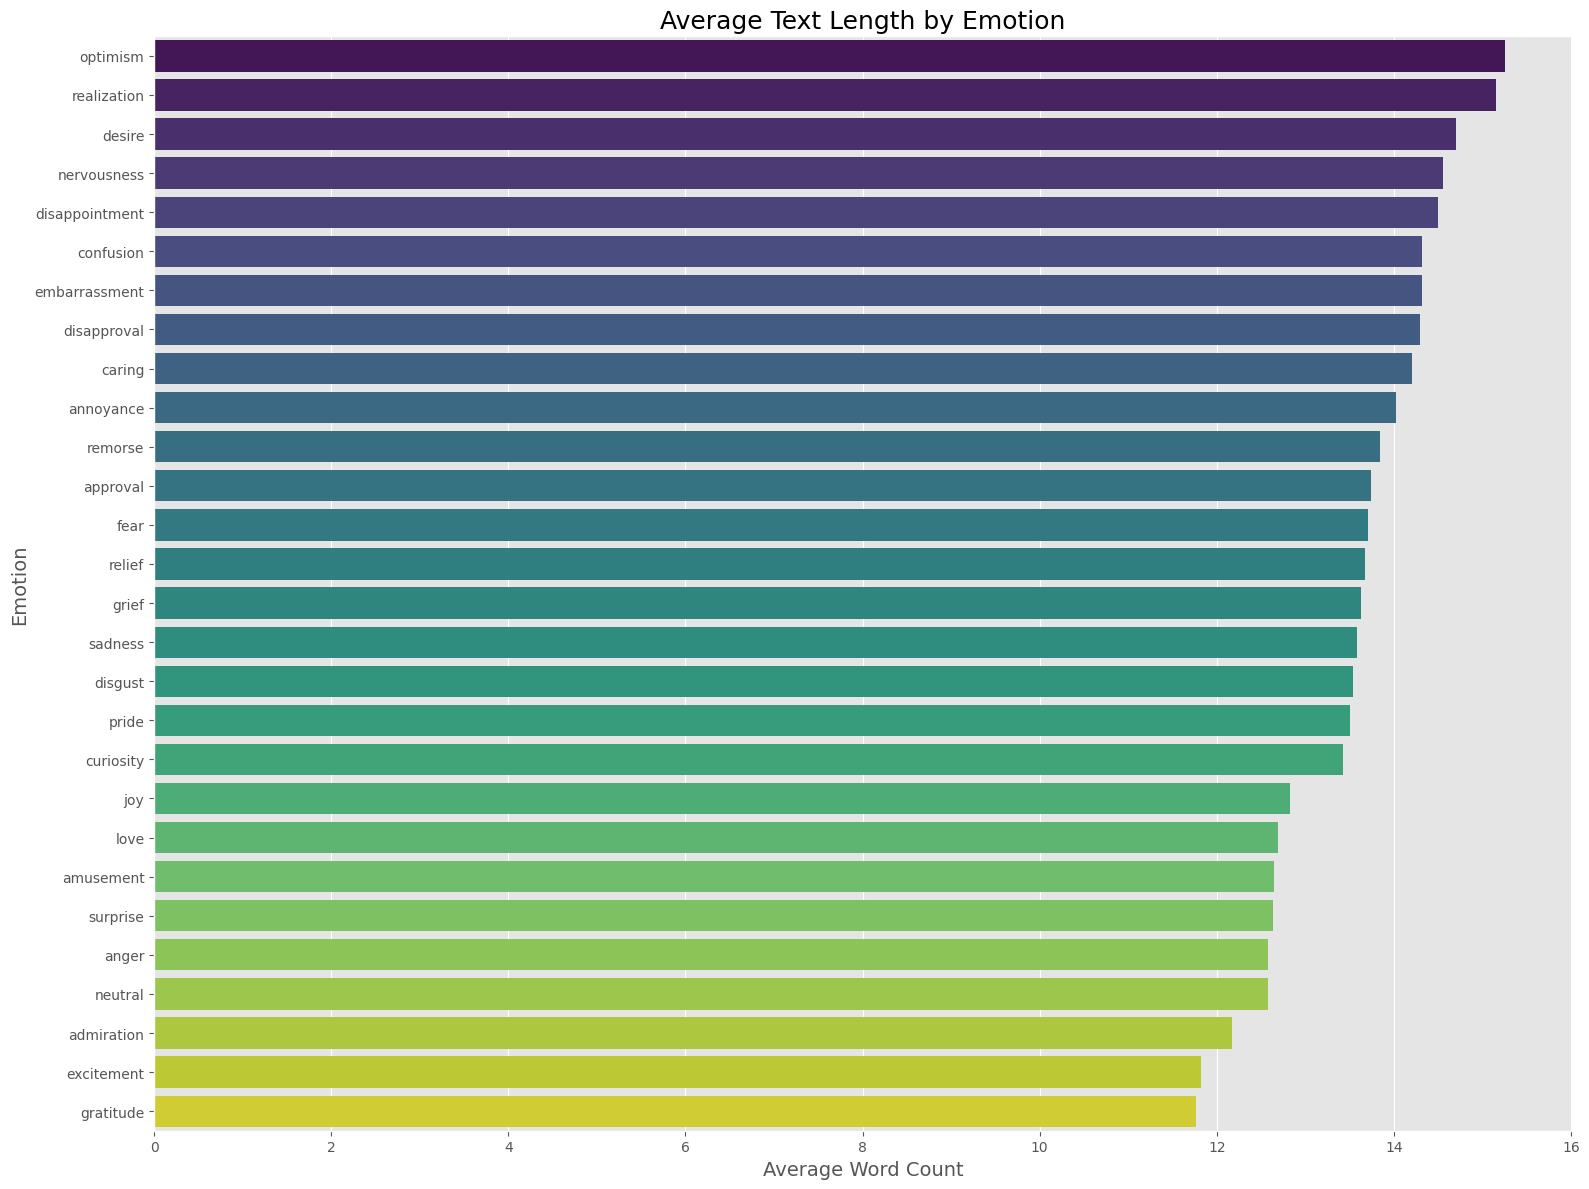

In [7]:
print("\n=== TEXT LENGTH BY EMOTION ===")
df['text_length'] = df['cleaned_text'].apply(lambda x: len(x.split()))
length_results = []

for emotion in emotion_cols:
    subset = df[df[emotion] == 1]
    if len(subset) > 0:
        lengths = subset['text_length']
        length_results.append({
            'emotion': emotion,
            'mean_length': lengths.mean(),
            'median_length': lengths.median(),
            'min_length': lengths.min(),
            'max_length': lengths.max()
        })

length_df = pd.DataFrame(length_results).sort_values('mean_length', ascending=False)

# Plot text length for all emotions
plt.figure(figsize=(16, 12))
sns.barplot(x='mean_length', y='emotion', data=length_df, palette='viridis')
plt.title('Average Text Length by Emotion', fontsize=18)
plt.xlabel('Average Word Count', fontsize=14)
plt.ylabel('Emotion', fontsize=14)
plt.tight_layout()
plt.show()

6. Emotion Co-occurrence Matrix


=== EMOTION CO-OCCURRENCE ===


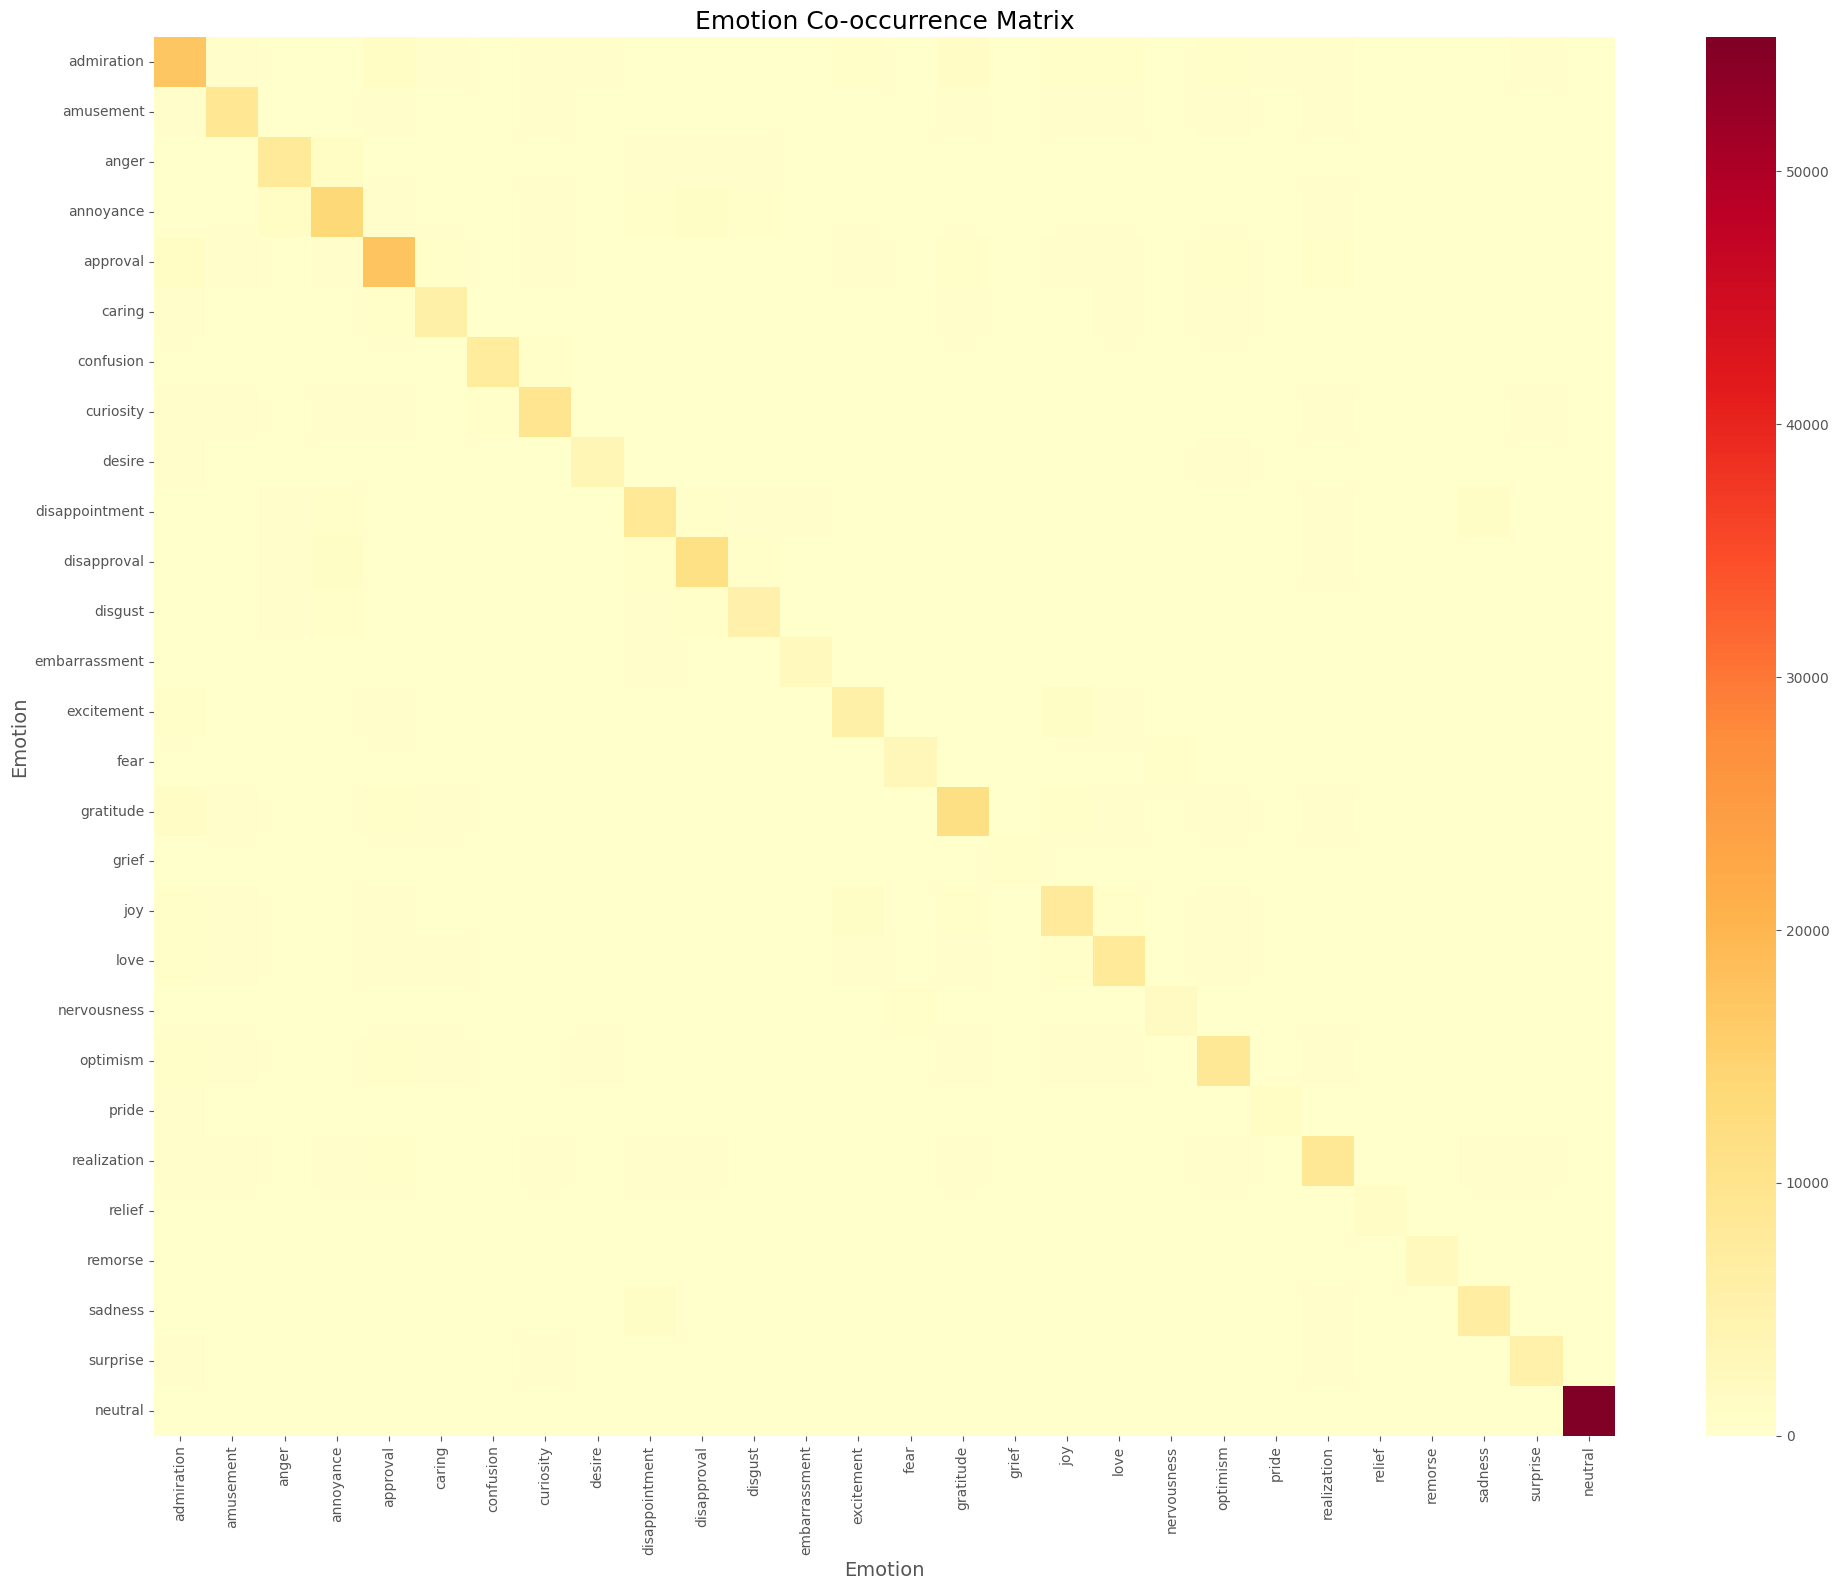


=== ANALYSIS COMPLETE FOR ALL 28 EMOTIONS ===


In [8]:
print("\n=== EMOTION CO-OCCURRENCE ===")
cooccurrence = df[emotion_cols].T.dot(df[emotion_cols])

plt.figure(figsize=(20, 16))
sns.heatmap(cooccurrence, cmap='YlOrRd', annot=False, fmt='d')
plt.title('Emotion Co-occurrence Matrix', fontsize=18)
plt.xlabel('Emotion', fontsize=14)
plt.ylabel('Emotion', fontsize=14)
plt.tight_layout()
plt.show()

print("\n=== ANALYSIS COMPLETE FOR ALL 28 EMOTIONS ===")

(2) EDA for Sentiment Analysis for Mental Health_reddit.csv contains the following:
- Word clouds for ALL statuses
- Status distribution
- Sentiment analysis by status
- Text length analysis

In [9]:
# Text cleaning
def clean_text(text):
    if not isinstance(text, str):
        return ""
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text, flags=re.MULTILINE)
    text = re.sub(r'\@\w+|\#', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

# Status word cloud function
def generate_status_wordcloud(text, title):
    wordcloud = WordCloud(width=1200, height=600,
                         background_color='white',
                         stopwords=set(STOPWORDS),
                         max_words=200,
                         colormap='viridis').generate(text)
    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(f'Status: {title}', fontsize=16, pad=20)
    plt.tight_layout()
    plt.show()

# Load data
print("Loading Mental Health Sentiment dataset...")
mental_health = pd.read_csv('Sentiment Analysis for Mental Health_reddit.csv')

# Clean data
mental_health_clean = mental_health.copy()
if mental_health_clean.columns[0] == 'Unnamed: 0':
    mental_health_clean = mental_health_clean.rename(columns={'Unnamed: 0': 'id'})

mental_health_clean['statement'] = mental_health_clean['statement'].fillna('')
mental_health_clean['status'] = mental_health_clean['status'].fillna('Unknown')
mental_health_clean['cleaned_text'] = mental_health_clean['statement'].apply(clean_text)

Loading Mental Health Sentiment dataset...


Basic information of the dataset and status distribution


=== BASIC DATASET INFO ===
Shape: (53044, 4)

Missing values:
id              1
statement       0
status          0
cleaned_text    0
dtype: int64

Status counts:
status
Normal                  16351
Depression              15404
Suicidal                10653
Anxiety                  3888
Bipolar                  2877
Stress                   2669
Personality disorder     1201
Unknown                     1
Name: count, dtype: int64


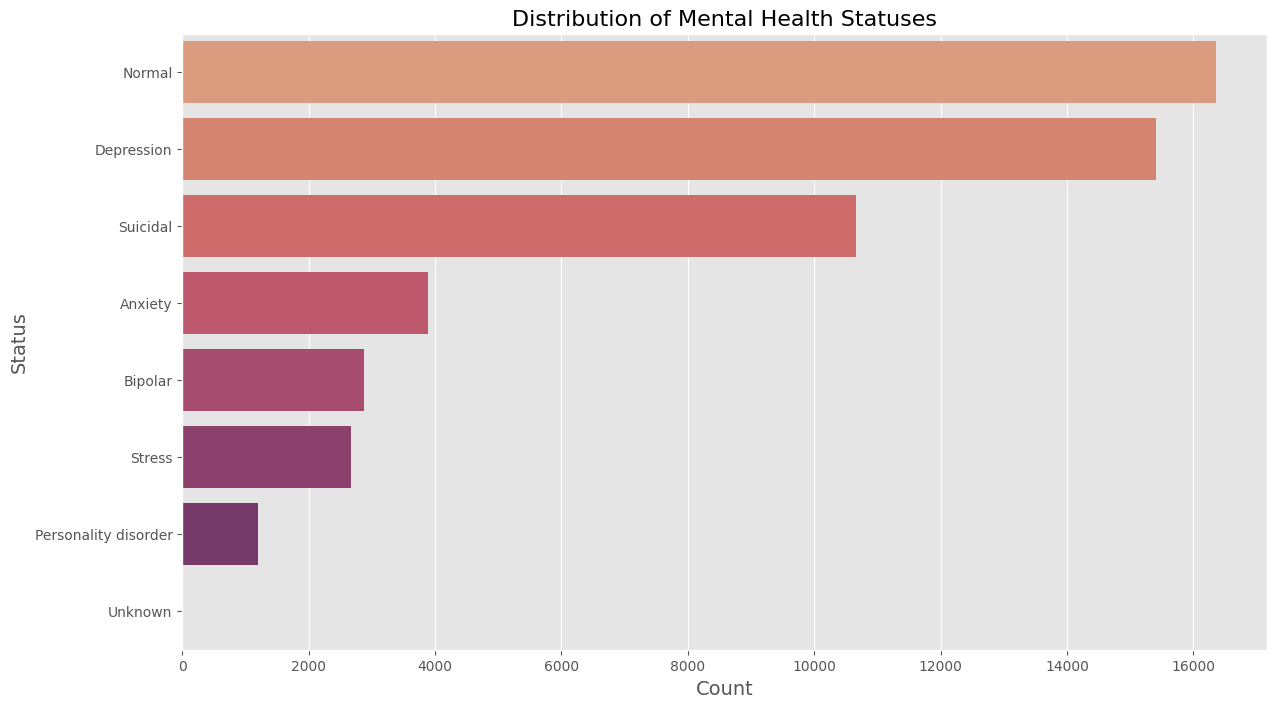

In [10]:
# Basic info
print("\n=== BASIC DATASET INFO ===")
print(f"Shape: {mental_health_clean.shape}")
print("\nMissing values:")
print(mental_health_clean.isnull().sum())

# Status distribution
status_counts = mental_health_clean['status'].value_counts()
print("\nStatus counts:")
print(status_counts)

plt.figure(figsize=(14, 8))
sns.barplot(x=status_counts.values, y=status_counts.index, palette='flare')
plt.title('Distribution of Mental Health Statuses', fontsize=16)
plt.xlabel('Count', fontsize=14)
plt.ylabel('Status', fontsize=14)
plt.show()

Word clouds for all mental health statuses

In [11]:
print("\n=== Mental health STATUS WORD CLOUDS ===")
for status in mental_health_clean['status'].unique():
    subset = mental_health_clean[mental_health_clean['status'] == status]
    if len(subset) >= 3:  # Minimum 3 samples
        combined_text = ' '.join(subset['cleaned_text'].astype(str))
        generate_status_wordcloud(combined_text, status)
    else:
        print(f"Skipping {status} - only {len(subset)} samples")

Output hidden; open in https://colab.research.google.com to view.

Sentiment analysis


=== SENTIMENT ANALYSIS ===


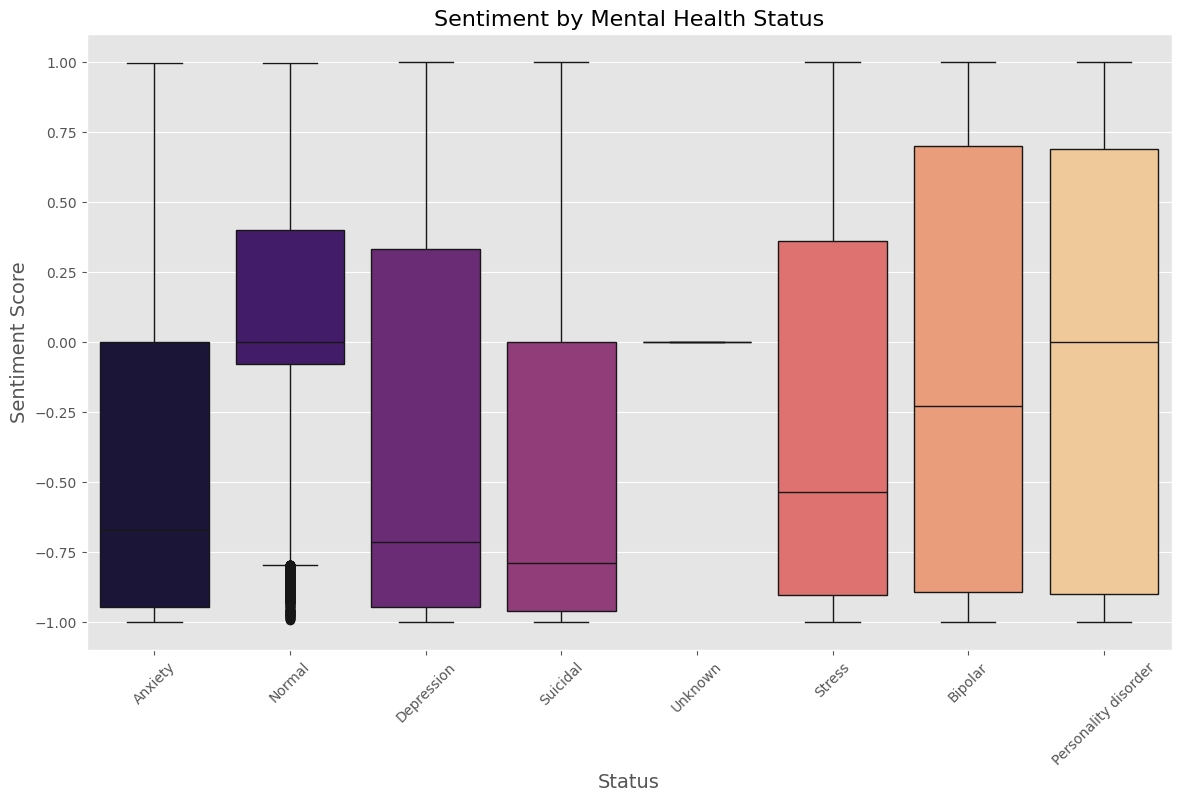

In [12]:
print("\n=== SENTIMENT ANALYSIS ===")
sia = SentimentIntensityAnalyzer()
mental_health_clean['sentiment'] = mental_health_clean['cleaned_text'].apply(
    lambda x: sia.polarity_scores(str(x))['compound'])

plt.figure(figsize=(14, 8))
sns.boxplot(x='status', y='sentiment', data=mental_health_clean, palette='magma')
plt.title('Sentiment by Mental Health Status', fontsize=16)
plt.xlabel('Status', fontsize=14)
plt.ylabel('Sentiment Score', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Text length analysis


=== TEXT LENGTH ANALYSIS ===
count    53044.000000
mean       112.120391
std        163.228632
min          0.000000
25%         15.000000
50%         61.000000
75%        147.000000
max       6300.000000
Name: text_length, dtype: float64


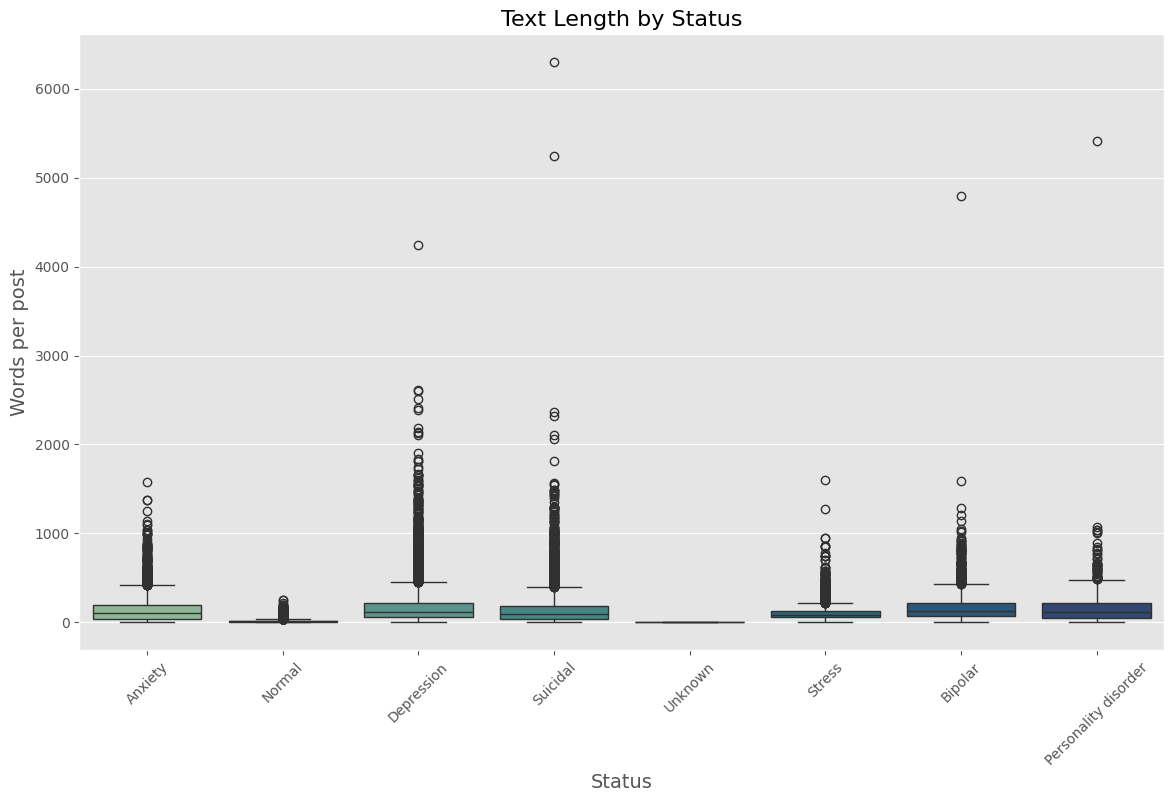

In [13]:
mental_health_clean['text_length'] = mental_health_clean['cleaned_text'].apply(lambda x: len(x.split()))
print("\n=== TEXT LENGTH ANALYSIS ===")
print(mental_health_clean['text_length'].describe())

plt.figure(figsize=(14, 8))
sns.boxplot(x='status', y='text_length', data=mental_health_clean, palette='crest')
plt.title('Text Length by Status', fontsize=16)
plt.xlabel('Status', fontsize=14)
plt.ylabel('Words per post', fontsize=14)
plt.xticks(rotation=45)
plt.show()

Detailed status analysis

In [14]:
print("\n=== DETAILED STATUS ANALYSIS ===")
for status in status_counts.index:
    subset = mental_health_clean[mental_health_clean['status'] == status]
    print(f"\nStatus: {status} (n={len(subset)})")
    print("Avg text length:", subset['text_length'].mean())
    print("Sentiment scores:")
    print(subset['sentiment'].describe())

print("\n===== MENTAL HEALTH SENTIMENT ANALYSIS COMPLETE =====")


=== DETAILED STATUS ANALYSIS ===

Status: Normal (n=16351)
Avg text length: 17.07944468228243
Sentiment scores:
count    16351.000000
mean         0.085448
std          0.423834
min         -0.990600
25%         -0.077200
50%          0.000000
75%          0.401900
max          0.998600
Name: sentiment, dtype: float64

Status: Depression (n=15404)
Avg text length: 167.7838223837964
Sentiment scores:
count    15404.000000
mean        -0.332957
std          0.722126
min         -0.999800
25%         -0.946625
50%         -0.714100
75%          0.332975
max          0.999600
Name: sentiment, dtype: float64

Status: Suicidal (n=10653)
Avg text length: 146.16877874777057
Sentiment scores:
count    10653.000000
mean        -0.428750
std          0.666868
min         -0.999900
25%         -0.959000
50%         -0.787100
75%          0.000000
max          0.999400
Name: sentiment, dtype: float64

Status: Anxiety (n=3888)
Avg text length: 141.63888888888889
Sentiment scores:
count    3888.0000